# คำถามข้อ 6 และ 7 — การถดถอยพหุคูณ (Modeling)

**ข้อ 6** เมื่อควบคุมการนอน คุณภาพการนอน การออกกำลังกาย ความกดดันจากการเรียน ผลการเรียน
และความเพียงพอทางการเงินแล้ว เวลาที่ใช้กับโซเชียลมีเดียยังอธิบายความแตกต่างของคะแนนแต่ละมิติได้อยู่หรือไม่

**ข้อ 7** ในกลุ่มนักศึกษาที่มีผลการเรียนและความเพียงพอทางการเงินใกล้เคียงกัน
ผู้ที่ใช้โซเชียลมีเดียมากกว่ามีคะแนนความเครียดต่างจากผู้ที่ใช้น้อยกว่าหรือไม่
— อ่านจากสัมประสิทธิ์ของ `social_media_hours` ในสมการความเครียด

สมการละหนึ่งมิติ ตาม `chapter/04-methodology.tex`

```
dass_<มิติ> ~ social_media_hours + news_days + sleep_hours + sleep_quality
            + exercise_days + study_pressure + GPA + financial_sufficiency
```

| ขั้น | ทำอะไร | ตอบอะไร |
|---|---|---|
| Hierarchical regression | block 1 ใส่ตัวแปรควบคุม 6 ตัว, block 2 เพิ่ม `social_media_hours` กับ `news_days` | ΔR² กับ F-change บอกว่าตัวแปรโซเชียลอธิบายอะไรเพิ่มจากตัวแปรควบคุมหรือไม่ (ข้อ 6) |
| ค่าสัมประสิทธิ์ | b, SE แบบ HC3, ช่วงความเชื่อมั่น 95%, β มาตรฐาน | ขนาดผลเป็นหน่วยคะแนน และเทียบน้ำหนักตัวแปรต้นด้วยกัน |
| Bonferroni | คูณค่า p ด้วย 3 เพราะทดสอบ 3 สมการ | กันผลบวกลวงจากการทดสอบซ้ำ |
| VIF, residual plot, Q-Q plot | ตรวจข้อตกลงเบื้องต้น | ใช้ผลของโมเดลได้หรือไม่ |

คะแนน DASS-21 เบ้ขวาและความแปรปรวนมักไม่คงที่ จึงใช้ SE แบบ HC3 กับค่าสัมประสิทธิ์
ส่วน F-change ใช้สูตรปกติเพื่อให้ตรงกับที่ SPSS รายงาน และแสดงค่า p แบบ HC3 ไว้เทียบ

รันจากโฟลเดอร์ `codingpy/` หรือจากรากของ repo ก็ได้ (เซลล์แรกเปลี่ยนโฟลเดอร์ให้)

In [ ]:
import os
import pathlib
import sys

# notebook.nvim starts the kernel in nvim's cwd; the shared modules and data/
# live in codingpy/, so step in there when the notebook is opened from the repo root
if pathlib.Path("codingpy/config.py").exists():
    os.chdir("codingpy")
sys.path.insert(0, os.getcwd())

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from clean_data import CLEAN_PATH
from config import load_data, setup
from IPython.display import display
from qr2 import COLOR, DIMENSION_TH, DIMENSIONS, thai_font
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# qr2 switches matplotlib to TkAgg on import; draw inside the notebook instead
%matplotlib inline
# notebook.nvim restyles matplotlib for a dark editor (white text, see-through
# background) when the kernel starts; the saved figures go on a white page
matplotlib.rcdefaults()
plt.rcParams["font.family"] = thai_font()

In [ ]:
ALPHA = 0.05
N_EQUATIONS = len(DIMENSIONS)  # one equation per dimension, so Bonferroni x3

EXPOSURES = ["social_media_hours", "news_days"]
CONTROLS = [
    "sleep_hours",
    "sleep_quality",
    "exercise_days",
    "study_pressure",
    "GPA",
    "financial_sufficiency",
]
PREDICTORS = EXPOSURES + CONTROLS

PREDICTOR_TH = {
    "social_media_hours": "ใช้โซเชียล (ชม./วัน)",
    "news_days": "เสพข่าว (วัน/สัปดาห์)",
    "sleep_hours": "ชั่วโมงนอน",
    "sleep_quality": "คุณภาพการนอน (1-10)",
    "exercise_days": "ออกกำลังกาย (วัน/สัปดาห์)",
    "study_pressure": "ความกดดันการเรียน (1-10)",
    "GPA": "เกรดเฉลี่ย",
    "financial_sufficiency": "ความพอของเงิน (1-10)",
}

INK = "#0b0b0b"
MUTED = "#52514e"
GRID = "#e5e4e0"
TITLE_SIZE = 21

FIG_PATH = "../figures/q6-regression.png"
TEST_PATH = "../figures/q0.png"
PARTIAL_FIG_PATH = "../figures/q7-partial-regression-stress.png"

## ข้อมูลที่ใช้

ตัดผู้ที่ไม่ผ่านข้อดักความใส่ใจออกตามที่เค้าโครงกำหนด แล้วใช้เฉพาะแถวที่ครบทุกตัวแปร
ทุกสมการจึงใช้ผู้ตอบชุดเดียวกัน ซึ่งจำเป็นสำหรับการเทียบ block 1 กับ block 2

In [ ]:
setup()
raw = load_data(CLEAN_PATH)

# the methodology drops every respondent who failed the attention check
passed = raw[raw["attention_check"] == 1]

# one complete-case sample for every model, so block 1 and block 2 are nested
# on the same rows and the F-change test is valid
df = passed[PREDICTORS + list(DIMENSIONS)].dropna().reset_index(drop=True)

print(f"{len(raw)} responses -> {len(passed)} passed the attention check -> {len(df)} complete cases")
print(f"{len(df) / len(PREDICTORS):.1f} respondents per predictor (rule of thumb: 10-20)")
display(df.describe().T[["mean", "std", "min", "max"]].round(2))

121 responses -> 107 passed the attention check -> 103 complete cases
12.9 respondents per predictor (rule of thumb: 10-20)


,mean,std,min,max
social_media_hours,7.87,2.73,4.0,15.5
news_days,3.45,1.51,1.0,7.0
sleep_hours,6.20,1.55,2.0,11.0
sleep_quality,5.50,2.16,1.0,10.0
exercise_days,2.02,1.83,0.0,7.0
study_pressure,6.17,2.26,1.0,10.0
GPA,3.20,0.49,2.0,4.0
financial_sufficiency,6.48,2.14,1.0,10.0
dass_depression,9.61,8.19,0.0,36.0
dass_anxiety,11.53,7.55,0.0,38.0


## ตัวแปรต้นสัมพันธ์กันเองหรือไม่ (VIF)

VIF เกิน 5 แปลว่าตัวแปรนั้นซ้ำกับตัวแปรต้นตัวอื่นมากจนค่าสัมประสิทธิ์เชื่อถือไม่ได้
VIF ไม่ดูตัวแปรตาม จึงพิมพ์ r ระหว่าง `study_pressure` กับ `dass_stress` แยกไว้
ตามข้อกังวลในเค้าโครงว่าสองตัวนี้วัดเรื่องใกล้กัน

In [ ]:
X = sm.add_constant(df[PREDICTORS])
vif = pd.Series(
    [variance_inflation_factor(X.to_numpy(), i) for i in range(1, X.shape[1])],
    index=PREDICTORS,
    name="VIF",
)
display(vif.round(2).to_frame())

r, p = stats.pearsonr(df["study_pressure"], df["dass_stress"])
print(f"study_pressure x dass_stress: r = {r:+.3f}, p = {p:.4f}")
r, p = stats.pearsonr(df["study_pressure"], df["GPA"])
print(f"study_pressure x GPA:         r = {r:+.3f}, p = {p:.4f}")

,VIF
social_media_hours,1.05
news_days,1.05
sleep_hours,1.36
sleep_quality,1.54
exercise_days,1.13
study_pressure,1.10
GPA,1.11
financial_sufficiency,1.15


study_pressure x dass_stress: r = +0.280, p = 0.0041
study_pressure x GPA:         r = +0.175, p = 0.0775


## ข้อ 6 — Hierarchical regression

block 1 มีแค่ตัวแปรควบคุม block 2 เพิ่มตัวแปรโซเชียลสองตัว
ถ้า ΔR² เล็กและ F-change ไม่มีนัยสำคัญ แปลว่าเมื่อรู้ตัวแปรควบคุมแล้ว การรู้เวลาใช้โซเชียลไม่ได้ช่วยอธิบายคะแนนเพิ่ม

In [ ]:
def formula(y: str, xs: list[str]) -> str:
    return f"{y} ~ " + " + ".join(xs)


def bonferroni(p: float) -> float:
    return min(1.0, p * N_EQUATIONS)


EXPOSURE_TEST = ", ".join(f"{x} = 0" for x in EXPOSURES)

models = {}  # dimension column -> block 2 fit with HC3 errors
rows = []
for col, name in DIMENSIONS.items():
    reduced = smf.ols(formula(col, CONTROLS), data=df).fit()
    full = smf.ols(formula(col, PREDICTORS), data=df).fit()
    models[col] = smf.ols(formula(col, PREDICTORS), data=df).fit(cov_type="HC3")

    # classic F-change, the number SPSS prints under "R Square Change"
    f_change, p_change, _ = full.compare_f_test(reduced)
    # the same two-coefficient test without assuming equal residual spread
    robust = models[col].wald_test(EXPOSURE_TEST, scalar=True)

    rows.append(
        {
            "dimension": name,
            "R2_block1": reduced.rsquared,
            "R2_block2": full.rsquared,
            "delta_R2": full.rsquared - reduced.rsquared,
            "F_change": f_change,
            "p_change": p_change,
            "p_bonferroni": bonferroni(p_change),
            "p_change_HC3": float(robust.pvalue),
            "adj_R2_block2": full.rsquared_adj,
        }
    )

blocks = pd.DataFrame(rows).set_index("dimension")
display(blocks.round(3))

,R2_block1,R2_block2,delta_R2,F_change,p_change,p_bonferroni,p_change_HC3,adj_R2_block2
dimension,,,,,,,,
Depression,0.263,0.271,0.008,0.489,0.615,1.000,0.584,0.208
Anxiety,0.058,0.103,0.045,2.355,0.100,0.301,0.073,0.027
Stress,0.191,0.205,0.013,0.796,0.454,1.000,0.456,0.137


## ค่าสัมประสิทธิ์ของสมการเต็ม

- **b** เมื่อตัวแปรต้นเพิ่ม 1 หน่วย โดยตัวแปรอื่นคงที่ คะแนนมิตินั้นเปลี่ยนกี่คะแนน (ค่าบวกคืออาการมากขึ้น)
- **β** ค่าเดียวกันในหน่วยส่วนเบี่ยงเบนมาตรฐาน ใช้เทียบว่าตัวแปรต้นตัวไหนน้ำหนักมากกว่า
- **p_bonferroni** ชุดทดสอบหลักคือ `social_media_hours` กับ `news_days` ส่วนตัวแปรควบคุมแสดงไว้ประกอบ

ระวังเครื่องหมาย: `sleep_quality` และ `financial_sufficiency` ยิ่งสูงยิ่งดี ค่า b ติดลบจึงแปลว่าดีขึ้นแล้วอาการลดลง

In [ ]:
# z-scored copy for standardized betas; same rows, same HC3 errors
z = (df - df.mean()) / df.std()

coef_rows = []
for col, name in DIMENSIONS.items():
    fit = models[col]
    std_fit = smf.ols(formula(col, PREDICTORS), data=z).fit(cov_type="HC3")
    ci = fit.conf_int()
    std_ci = std_fit.conf_int()
    for x in PREDICTORS:
        coef_rows.append(
            {
                "dimension": name,
                "predictor": x,
                "b": fit.params[x],
                "SE_HC3": fit.bse[x],
                "ci_low": ci.loc[x, 0],
                "ci_high": ci.loc[x, 1],
                "p": fit.pvalues[x],
                "p_bonferroni": bonferroni(fit.pvalues[x]),
                "beta": std_fit.params[x],
                "beta_low": std_ci.loc[x, 0],
                "beta_high": std_ci.loc[x, 1],
            }
        )
coefs = pd.DataFrame(coef_rows)

for name in DIMENSIONS.values():
    print(f"\n{name}  (R² = {blocks.loc[name, 'R2_block2']:.3f}, adj R² = {blocks.loc[name, 'adj_R2_block2']:.3f}, n = {len(df)})")
    table = coefs[coefs["dimension"] == name].drop(columns=["dimension", "beta_low", "beta_high"])
    display(table.set_index("predictor").round(3))


Depression  (R² = 0.271, adj R² = 0.208, n = 103)

,b,SE_HC3,ci_low,ci_high,p,p_bonferroni,beta
predictor,,,,,,,
social_media_hours,-0.268,0.258,-0.775,0.238,0.299,0.898,-0.089
news_days,0.023,0.482,-0.921,0.967,0.961,1.000,0.004
sleep_hours,1.150,0.624,-0.073,2.373,0.065,0.196,0.217
sleep_quality,-0.921,0.416,-1.736,-0.106,0.027,0.080,-0.242
exercise_days,0.176,0.445,-0.696,1.049,0.692,1.000,0.039
study_pressure,0.979,0.373,0.247,1.710,0.009,0.026,0.269
GPA,-0.706,1.581,-3.805,2.393,0.655,1.000,-0.042
financial_sufficiency,-1.125,0.333,-1.777,-0.472,0.001,0.002,-0.293



Anxiety  (R² = 0.103, adj R² = 0.027, n = 103)


,b,SE_HC3,ci_low,ci_high,p,p_bonferroni,beta
predictor,,,,,,,
social_media_hours,-0.391,0.273,-0.926,0.145,0.153,0.459,-0.141
news_days,0.872,0.496,-0.100,1.844,0.079,0.236,0.174
sleep_hours,0.069,0.556,-1.021,1.159,0.901,1.000,0.014
sleep_quality,-0.162,0.370,-0.887,0.564,0.663,1.000,-0.046
exercise_days,-0.066,0.443,-0.935,0.803,0.882,1.000,-0.016
study_pressure,0.329,0.386,-0.428,1.087,0.394,1.000,0.098
GPA,-0.958,1.516,-3.928,2.013,0.528,1.000,-0.062
financial_sufficiency,-0.663,0.336,-1.322,-0.005,0.048,0.145,-0.188



Stress  (R² = 0.205, adj R² = 0.137, n = 103)


,b,SE_HC3,ci_low,ci_high,p,p_bonferroni,beta
predictor,,,,,,,
social_media_hours,-0.187,0.268,-0.713,0.338,0.485,1.000,-0.066
news_days,0.534,0.512,-0.470,1.537,0.297,0.892,0.103
sleep_hours,0.195,0.555,-0.893,1.284,0.725,1.000,0.039
sleep_quality,-0.878,0.435,-1.731,-0.025,0.044,0.131,-0.243
exercise_days,-0.185,0.433,-1.033,0.663,0.669,1.000,-0.044
study_pressure,0.800,0.383,0.049,1.551,0.037,0.110,0.232
GPA,0.115,1.592,-3.005,3.236,0.942,1.000,0.007
financial_sufficiency,-0.626,0.357,-1.325,0.074,0.079,0.238,-0.172


## ข้อ 7 — โซเชียลมีเดียกับความเครียด เมื่อผลการเรียนและการเงินเท่ากัน

ค่าสัมประสิทธิ์ของ `social_media_hours` ในสมการความเครียดคือผลที่คุม `GPA` และ `financial_sufficiency`
(และตัวแปรอื่นทั้งหมด) ไว้แล้ว

Partial regression plot หักผลของตัวแปรต้นตัวอื่นออกจากทั้งแกน x และแกน y ก่อน
ความชันของเส้นในกราฟจึงเท่ากับค่า b ในตารางพอดี

social_media_hours -> stress: b = -0.187 points per extra hour/day (95% CI -0.713, +0.338), p = 0.485, Bonferroni p = 1.000


saved: ../figures/q7-partial-regression-stress.png


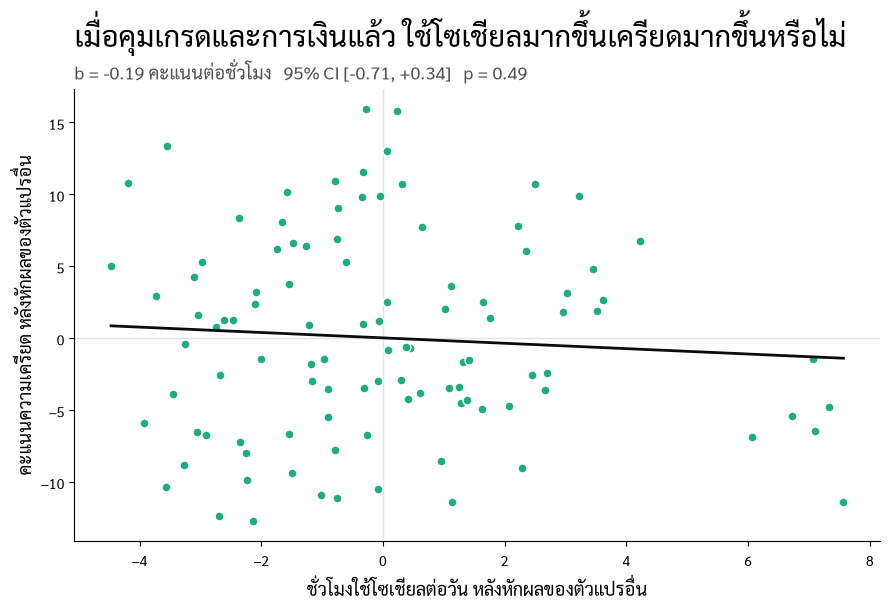

In [ ]:
stress = models["dass_stress"]
b = stress.params["social_media_hours"]
lo, hi = stress.conf_int().loc["social_media_hours"]
p = stress.pvalues["social_media_hours"]
print(
    f"social_media_hours -> stress: b = {b:+.3f} points per extra hour/day "
    f"(95% CI {lo:+.3f}, {hi:+.3f}), p = {p:.3f}, Bonferroni p = {bonferroni(p):.3f}"
)


def residualize(y: str, xs: list[str]) -> np.ndarray:
    """What is left of y once xs have explained what they can."""
    return smf.ols(formula(y, xs), data=df).fit().resid.to_numpy()


others = [x for x in PREDICTORS if x != "social_media_hours"]
ex = residualize("social_media_hours", others)
ey = residualize("dass_stress", others)

fig, ax = plt.subplots(figsize=(9, 6.2))
ax.scatter(ex, ey, s=42, color=COLOR["Stress"], edgecolor="white", linewidth=1, zorder=3)
xs = np.linspace(ex.min(), ex.max(), 2)
ax.plot(xs, b * xs, color=INK, linewidth=2, zorder=4)
ax.axhline(0, color=GRID, linewidth=1, zorder=1)
ax.axvline(0, color=GRID, linewidth=1, zorder=1)
ax.annotate(
    f"b = {b:+.2f} คะแนนต่อชั่วโมง   95% CI [{lo:+.2f}, {hi:+.2f}]   p = {p:.2f}",
    (0.0, 1.02),
    xycoords="axes fraction",
    fontsize=13,
    color=MUTED,
)
ax.set_title(
    "เมื่อคุมเกรดและการเงินแล้ว ใช้โซเชียลมากขึ้นเครียดมากขึ้นหรือไม่",
    loc="left",
    fontsize=TITLE_SIZE,
    pad=30,
)
ax.set_xlabel("ชั่วโมงใช้โซเชียลต่อวัน หลังหักผลของตัวแปรอื่น", fontsize=13)
ax.set_ylabel("คะแนนความเครียด หลังหักผลของตัวแปรอื่น", fontsize=13)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(PARTIAL_FIG_PATH, dpi=200, facecolor="white")
print(f"saved: {PARTIAL_FIG_PATH}")
plt.show()

## ตรวจข้อตกลงเบื้องต้น

- **Residual vs fitted** จุดควรกระจายรอบ 0 เท่า ๆ กันโดยไม่เป็นรูปกรวยหรือโค้ง
- **Q-Q plot** จุดควรอยู่บนเส้นตรง ถ้าปลายเชิดขึ้นแปลว่าค่าคลาดเคลื่อนเบ้
- **Breusch-Pagan** p < 0.05 แปลว่าความแปรปรวนไม่คงที่ ซึ่งเป็นเหตุผลที่ใช้ SE แบบ HC3
- **Shapiro-Wilk** p < 0.05 แปลว่าค่าคลาดเคลื่อนไม่ปกติ ที่ n ราว 100 ยังพอรับได้ถ้าไม่เบ้มาก

Depression  Breusch-Pagan p = 0.013   Shapiro-Wilk p = 0.180
Anxiety     Breusch-Pagan p = 0.921   Shapiro-Wilk p = 0.001
Stress      Breusch-Pagan p = 0.185   Shapiro-Wilk p = 0.161


saved: ../figures/q0.png


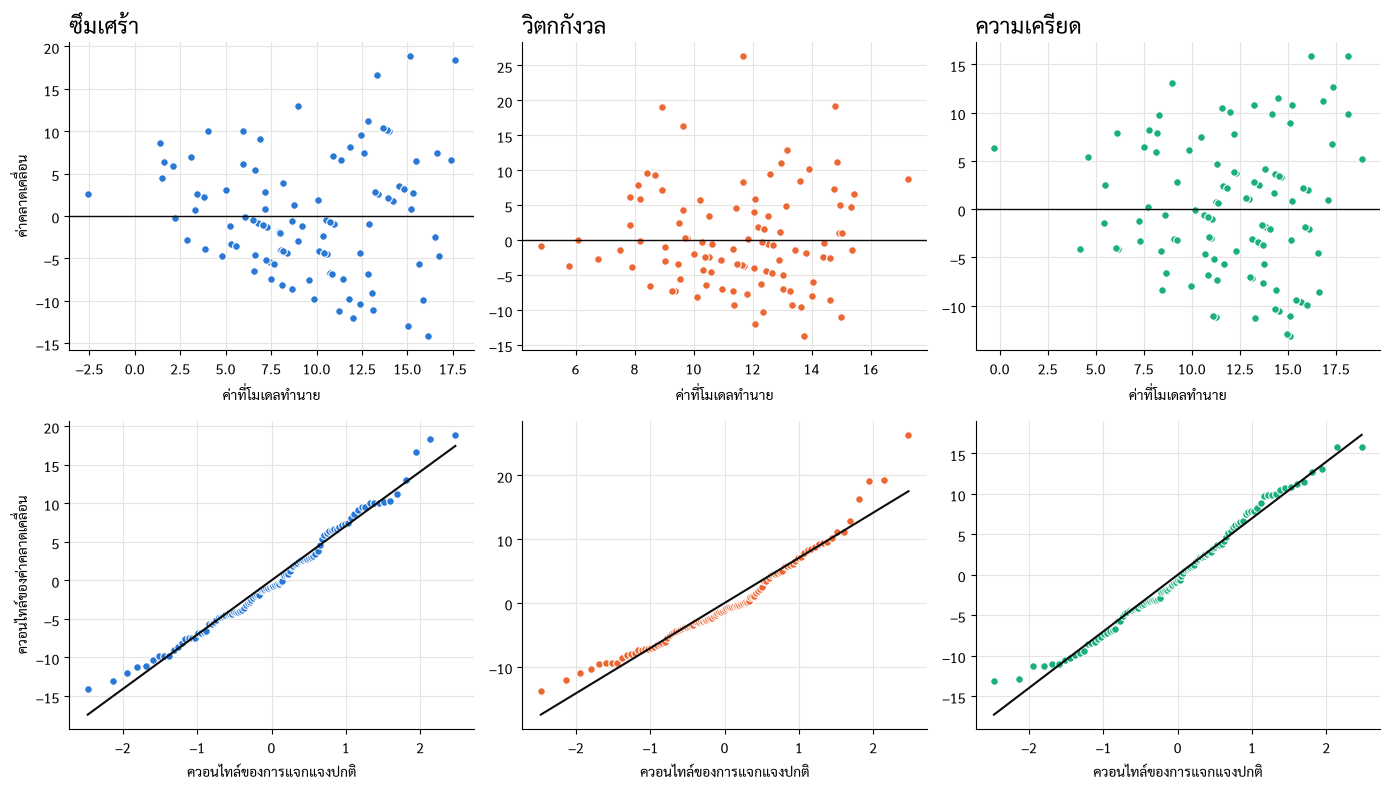

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, (col, name) in enumerate(DIMENSIONS.items()):
    fit = models[col]
    resid = fit.resid.to_numpy()

    ax = axes[0, i]
    ax.scatter(fit.fittedvalues, resid, s=30, color=COLOR[name], edgecolor="white", linewidth=0.8)
    ax.axhline(0, color=INK, linewidth=1)
    ax.set_title(DIMENSION_TH[name], fontsize=16, loc="left")
    ax.set_xlabel("ค่าที่โมเดลทำนาย")
    if i == 0:
        ax.set_ylabel("ค่าคลาดเคลื่อน")

    ax = axes[1, i]
    (osm, osr), (slope, intercept, _) = stats.probplot(resid)
    ax.scatter(osm, osr, s=30, color=COLOR[name], edgecolor="white", linewidth=0.8)
    ax.plot(osm, slope * osm + intercept, color=INK, linewidth=1.5)
    ax.set_xlabel("ควอนไทล์ของการแจกแจงปกติ")
    if i == 0:
        ax.set_ylabel("ควอนไทล์ของค่าคลาดเคลื่อน")

    bp = het_breuschpagan(resid, fit.model.exog)[1]
    sw = stats.shapiro(resid).pvalue
    print(f"{name:<11} Breusch-Pagan p = {bp:.3f}   Shapiro-Wilk p = {sw:.3f}")

for ax in axes.flat:
    ax.grid(color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(TEST_PATH, dpi=200, facecolor="white")
print(f"saved: {TEST_PATH}")
plt.show()

In [ ]:
plt.show()

## ความทนทานของผล (sensitivity)

ผลข้อ 6 ไม่ควรเปลี่ยนเพราะการตัดสินใจเล็ก ๆ จึงรันซ้ำสองแบบ

1. ตัด `study_pressure` ออกจากสมการความเครียด ตามแผนในเค้าโครงกรณีที่สองตัวนี้ซ้อนกัน
2. ใช้ผู้ตอบทั้งหมดรวมคนที่ไม่ผ่านข้อดัก ซึ่งเป็นชุดเดียวกับที่สคริปต์ข้ออื่นใช้

ถ้า b ของ `social_media_hours` ไม่เปลี่ยนเครื่องหมายและข้อสรุปเรื่องนัยสำคัญเหมือนเดิม ผลถือว่าทนทาน

In [ ]:
everyone = raw[PREDICTORS + list(DIMENSIONS)].dropna()
no_pressure = [x for x in PREDICTORS if x != "study_pressure"]

variants = [
    ("main model", df, PREDICTORS, list(DIMENSIONS)),
    ("stress without study_pressure", df, no_pressure, ["dass_stress"]),
    ("all respondents", everyone, PREDICTORS, list(DIMENSIONS)),
]

rows = []
for label, data, xs, ys in variants:
    for col in ys:
        fit = smf.ols(formula(col, xs), data=data).fit(cov_type="HC3")
        rows.append(
            {
                "variant": label,
                "dimension": DIMENSIONS[col],
                "n": int(fit.nobs),
                "b_social_media": fit.params["social_media_hours"],
                "p_social_media": fit.pvalues["social_media_hours"],
                "b_news": fit.params["news_days"],
                "p_news": fit.pvalues["news_days"],
                "R2": fit.rsquared,
            }
        )
display(pd.DataFrame(rows).set_index(["variant", "dimension"]).round(3))

n  b_social_media  p_social_media  b_news  p_news  \
variant                       dimension                                                         
main model                    Depression  103          -0.268           0.299   0.023   0.961   
                              Anxiety     103          -0.391           0.153   0.872   0.079   
                              Stress      103          -0.187           0.485   0.534   0.297   
stress without study_pressure Stress      103          -0.167           0.537   0.644   0.193   
all respondents               Depression  116          -0.224           0.377   0.092   0.846   
                              Anxiety     116          -0.210           0.420   0.965   0.040   
                              Stress      116          -0.071           0.790   0.620   0.198   

                                             R2  
variant                       dimension          
main model                    Depression  0.271  
                              Anxiety     0.103  
                              Stress      0.205  
stress without study_pressure Stress      0.156  
all respondents               Depression  0.298  
                              Anxiety     0.118  
                              Stress      0.220

## กราฟสรุป — β มาตรฐานของทุกตัวแปรต้น แยกตามมิติ

หนึ่งช่องต่อหนึ่งมิติ จุดคือ β และเส้นคือช่วงความเชื่อมั่น 95%
จุดทึบคือมีนัยสำคัญหลังปรับ Bonferroni ส่วนจุดโปร่งคือไม่มี
ทุกช่องใช้แกน x เดียวกัน จึงเทียบความยาวข้ามมิติได้ตรง ๆ

saved: ../figures/q6-regression.png


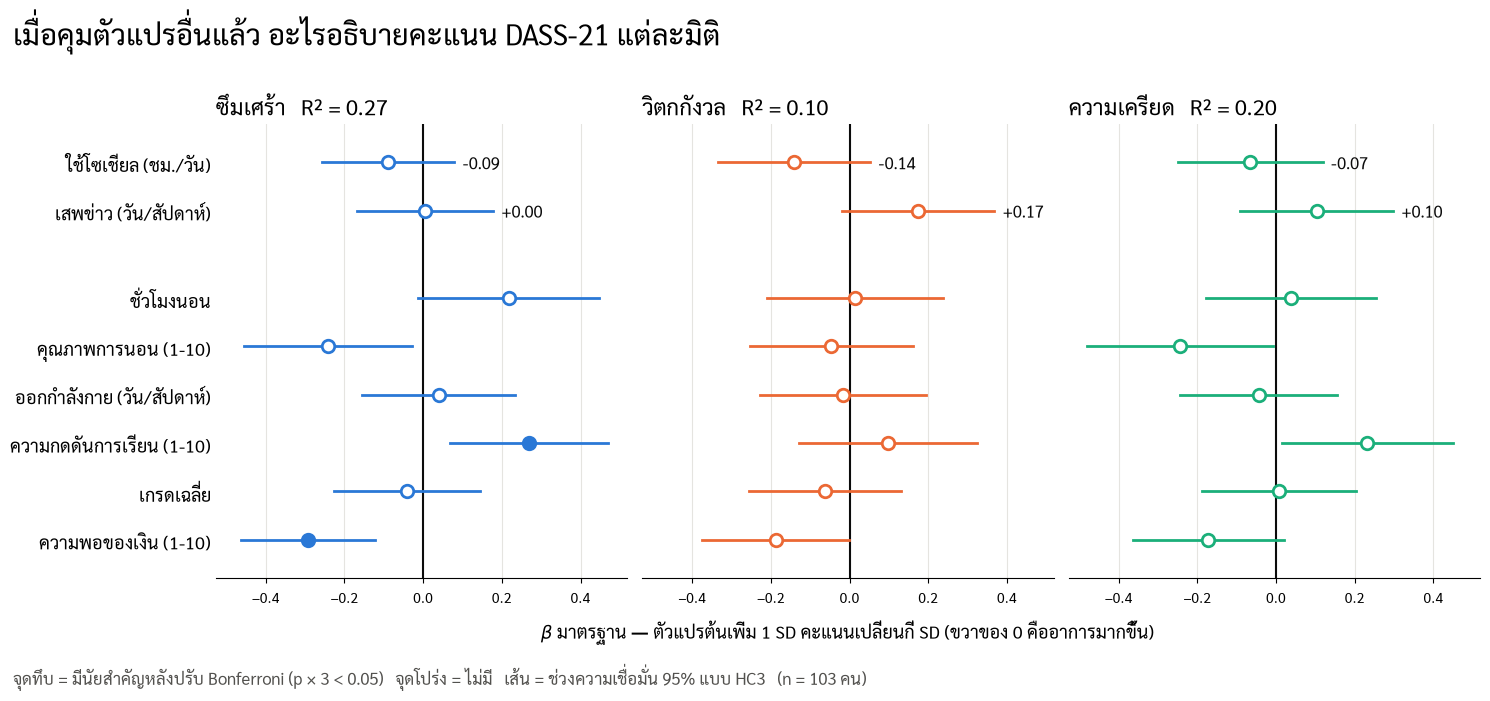

In [ ]:
# rows top to bottom: the two exposures, a gap, then the six controls
positions = {}
y = 0.0
for block, group in enumerate((EXPOSURES, CONTROLS)):
    if block:
        y -= 0.8
    for x in group:
        positions[x] = y
        y -= 1.0

fig, axes = plt.subplots(1, 3, figsize=(15, 7), sharey=True, sharex=True)
for ax, (col, name) in zip(axes, DIMENSIONS.items()):
    color = COLOR[name]
    rows = coefs[coefs["dimension"] == name].set_index("predictor")
    for x, y in positions.items():
        row = rows.loc[x]
        significant = row["p_bonferroni"] < ALPHA
        ax.plot([row["beta_low"], row["beta_high"]], [y, y], color=color, linewidth=2, zorder=2)
        # filled = significant after Bonferroni, hollow = not; fill carries it, not hue
        ax.plot(
            row["beta"],
            y,
            "o",
            markersize=9,
            color=color,
            markerfacecolor=color if significant else "white",
            markeredgewidth=2,
            zorder=3,
        )
        # numbers only on the two exposures, which are what the question asks about
        if x in EXPOSURES:
            ax.annotate(
                f"{row['beta']:+.2f}",
                (row["beta_high"], y),
                textcoords="offset points",
                xytext=(6, 0),
                va="center",
                fontsize=12,
                color=INK,
            )

    ax.axvline(0, color=INK, linewidth=1.5, zorder=1)
    ax.grid(axis="x", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.set_title(
        f"{DIMENSION_TH[name]}   R² = {blocks.loc[name, 'R2_block2']:.2f}",
        loc="left",
        fontsize=16,
    )

axes[0].set_yticks(list(positions.values()))
axes[0].set_yticklabels([PREDICTOR_TH[x] for x in positions], fontsize=13)
axes[0].set_ylim(min(positions.values()) - 0.8, max(positions.values()) + 0.8)
axes[1].set_xlabel(
    "$\\beta$ มาตรฐาน — ตัวแปรต้นเพิ่ม 1 SD คะแนนเปลี่ยนกี่ SD (ขวาของ 0 คืออาการมากขึ้น)",
    fontsize=13,
    labelpad=10,
)

fig.suptitle(
    "เมื่อคุมตัวแปรอื่นแล้ว อะไรอธิบายคะแนน DASS-21 แต่ละมิติ",
    x=0.012,
    ha="left",
    fontsize=TITLE_SIZE,
)
fig.tight_layout(rect=(0, 0.05, 1, 0.97))
fig.text(
    0.012,
    0.015,
    "จุดทึบ = มีนัยสำคัญหลังปรับ Bonferroni (p × 3 < 0.05)   จุดโปร่ง = ไม่มี   "
    f"เส้น = ช่วงความเชื่อมั่น 95% แบบ HC3   (n = {len(df)} คน)",
    fontsize=12,
    color=MUTED,
)
fig.savefig(FIG_PATH, dpi=200, facecolor="white")
print(f"saved: {FIG_PATH}")
plt.show()

## วิธีอ่านผลไปเขียนรายงาน

1. ดูตาราง hierarchical ก่อน: ΔR² บอกว่าตัวแปรโซเชียลอธิบายความแปรปรวนเพิ่มกี่เปอร์เซ็นต์ ส่วน `p_bonferroni` บอกว่าเพิ่มอย่างมีนัยสำคัญหรือไม่
2. ถ้าไม่มีนัยสำคัญ ให้เขียนว่า "เมื่อควบคุมปัจจัยอื่นแล้ว ไม่พบว่าเวลาที่ใช้โซเชียลมีเดียอธิบายคะแนนเพิ่มเติม" ไม่ใช่ "โซเชียลมีเดียไม่มีผล" เพราะช่วงความเชื่อมั่นยังกว้างพอจะมีผลเล็ก ๆ ซ่อนอยู่
3. ใช้ β ในกราฟสรุปเพื่อชี้ว่าตัวแปรใดน้ำหนักมากที่สุดในแต่ละมิติ
4. ข้อมูลเก็บครั้งเดียว จึงเขียนได้แค่ "สัมพันธ์กับ" ห้ามเขียนว่า "ทำให้"